In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('heart.csv')

In [5]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


EDA

In [6]:
df.shape

(918, 12)

In [7]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [9]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['HeartDisease'].value_counts()

,count
HeartDisease,
1,508
0,410


<Axes: ylabel='count'>

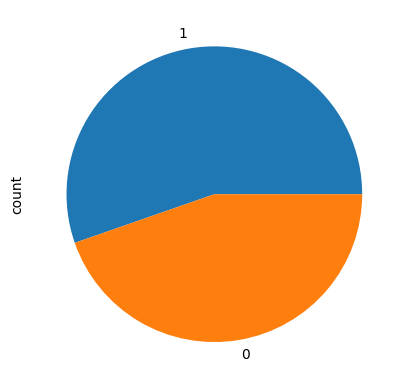

In [12]:
df['HeartDisease'].value_counts().plot(kind='pie')

In [13]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [14]:
def plotting(var,num):
  plt.subplot(2,2,num)
  sns.histplot(df[var],kde=True)
  plt.title(var)

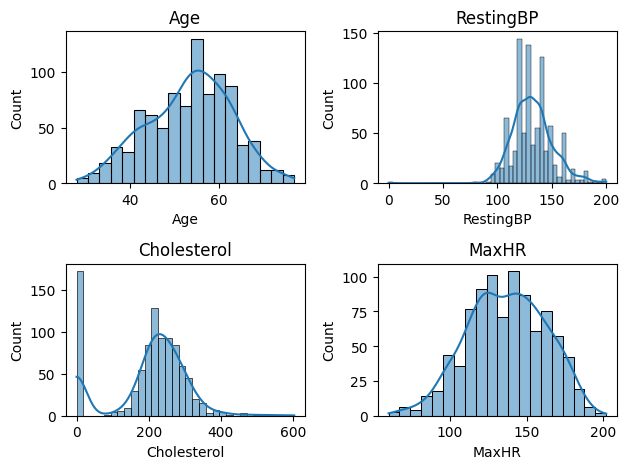

In [15]:
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)


plt.tight_layout()#to remove ooverlap

In [16]:
df['Cholesterol'].value_counts()

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9
...,...
353,1
278,1
157,1


data cleaning ( beacause cholesttol cant be zero and also restingbp cant be zero)

In [17]:
ch_mean =df.loc[df['Cholesterol']!=0, "Cholesterol"].mean()

In [18]:
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)

In [19]:
df['Cholesterol'] = df['Cholesterol'].round(2)

In [20]:
rest_bp_mean =df.loc[df['RestingBP'] !=0, "RestingBP"].mean()

In [21]:
df['RestingBP'] = df['RestingBP'].replace(0,rest_bp_mean)

In [22]:
df['RestingBP'] = df['RestingBP'].round(2)

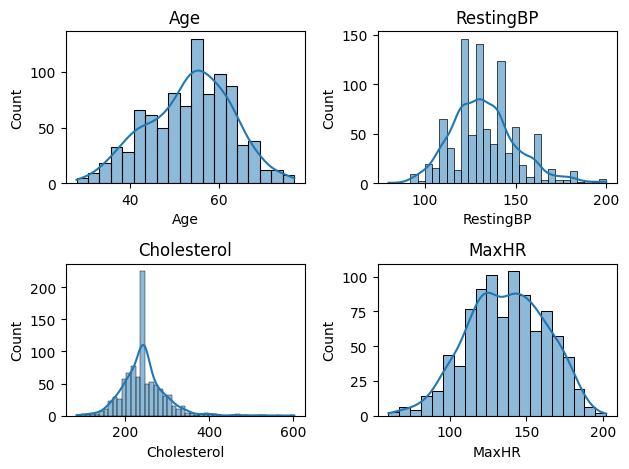

In [23]:
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()#to remove ooverlap


In [24]:
pip install sheryanalysis

In [25]:
import sheryanalysis as sh

In [26]:
sh.analyze(df)


🔍 Basic Analysis Report


INFO:sheryanalysis:
🔍 Basic Analysis Report


------------------------------------------------------------


INFO:sheryanalysis:------------------------------------------------------------


📏 Shape: (918, 12)


...


🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']


INFO:sheryanalysis:
🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']



🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


INFO:sheryanalysis:
🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


{'shape': (918, 12),
 'columns': ['Age',
  'Sex',
  'ChestPainType',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'RestingECG',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ST_Slope',
  'HeartDisease'],
 'dtypes': {'Age': dtype('int64'),
  'Sex': dtype('O'),
  'ChestPainType': dtype('O'),
  'RestingBP': dtype('float64'),
  'Cholesterol': dtype('float64'),
  'FastingBS': dtype('int64'),
  'RestingECG': dtype('O'),
  'MaxHR': dtype('int64'),
  'ExerciseAngina': dtype('O'),
  'Oldpeak': dtype('float64'),
  'ST_Slope': dtype('O'),
  'HeartDisease': dtype('int64')},
 'null_counts': {'Age': 0,
  'Sex': 0,
  'ChestPainType': 0,
  'RestingBP': 0,
  'Cholesterol': 0,
  'FastingBS': 0,
  'RestingECG': 0,
  'MaxHR': 0,
  'ExerciseAngina': 0,
  'Oldpeak': 0,
  'ST_Slope': 0,
  'HeartDisease': 0},
 'total_rows': 918,
 'column_types': {'categorical': ['Sex',
   'ChestPainType',
   'FastingBS',
   'RestingECG',
   'ExerciseAngina',
   'ST_Slope',
   'HeartDisease'],
  'numerical': ['Age', 'Rest

<Axes: xlabel='count', ylabel='Sex'>

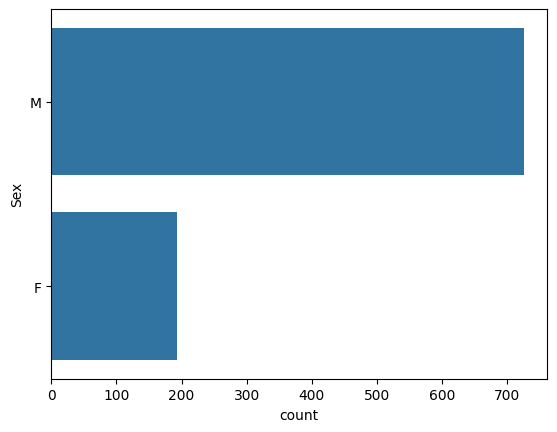

In [27]:
sns.countplot(df['Sex'])

COUNT PLOT IS BEST FOR categorical varaible
BOX PLOT IS BEST FOR COMPARING
categorial varaible and normal varaible

<Axes: xlabel='ChestPainType', ylabel='count'>

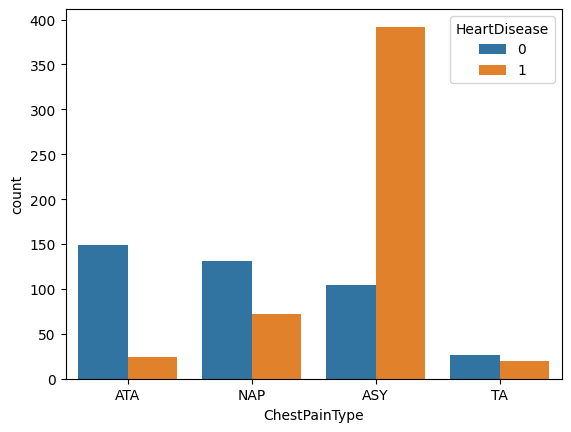

In [28]:
sns.countplot(data=df, x='ChestPainType', hue='HeartDisease')

<Axes: xlabel='FastingBS', ylabel='count'>

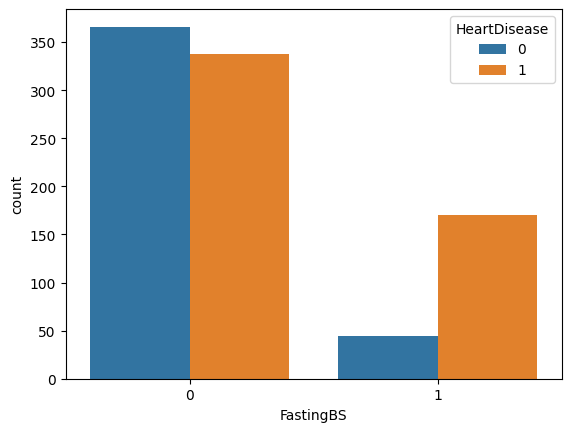

In [29]:
sns.countplot(data=df, x='FastingBS', hue='HeartDisease')

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

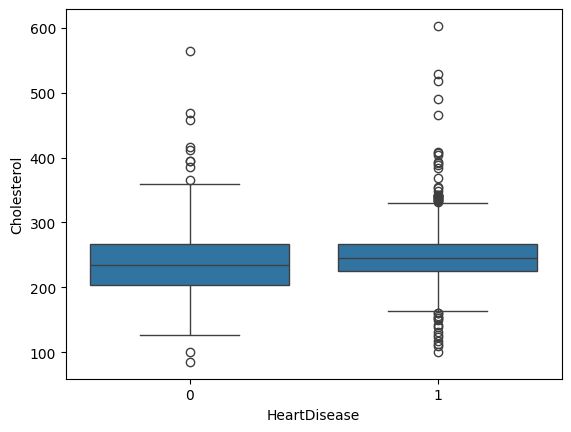

In [30]:
sns.boxplot(data=df, x='HeartDisease', y='Cholesterol')

<Axes: xlabel='HeartDisease', ylabel='Age'>

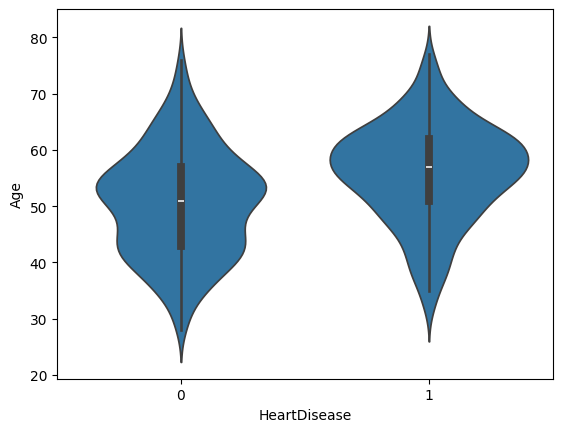

In [31]:
sns.violinplot(data=df, x='HeartDisease', y='Age')

<Axes: >

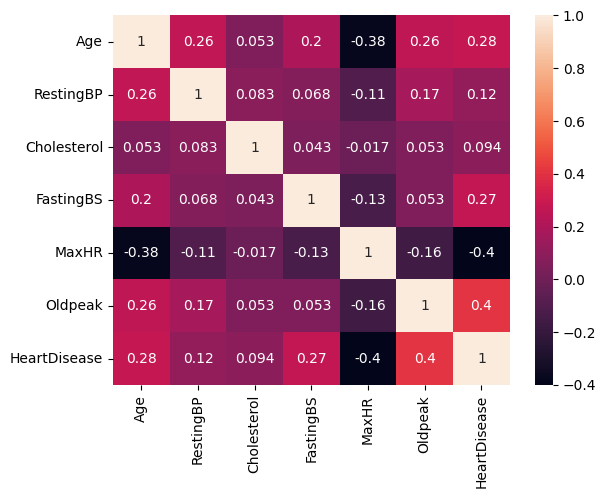

In [32]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

DATA PREPROCESSING AND CLEANING

In [33]:
df_encode = pd.get_dummies(df, drop_first=True)

In [34]:
df_encode =df_encode.astype(int)

In [35]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,0,1,0,0,0,0,0,1,0


In [36]:
from sklearn.preprocessing import StandardScaler
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', "Oldpeak"]
scaler = StandardScaler()
df_encode[numeric_cols] = scaler.fit_transform(df_encode[numeric_cols])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

In [38]:
X = df_encode.drop('HeartDisease', axis=1)
y = df_encode['HeartDisease']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20 , random_state=42)

In [40]:
from numpy.random import logistic
models= {
    "logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

In [41]:
result = []

In [42]:
for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  result.append({
      'model': name,
      'accuracy': round(accuracy,4),
      'f1': round(f1,4),
      })

In [43]:
result

[{'model': 'logistic Regression', 'accuracy': 0.8587, 'f1': 0.8738},
 {'model': 'Decision Tree', 'accuracy': 0.7772, 'f1': 0.794},
 {'model': 'Naive Bayes', 'accuracy': 0.8478, 'f1': 0.8614},
 {'model': 'KNN', 'accuracy': 0.837, 'f1': 0.8558},
 {'model': 'SVM', 'accuracy': 0.8478, 'f1': 0.8679}]

In [44]:
import joblib
joblib.dump(models['logistic Regression'], 'heart_disease_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'columns.pkl') # Converts the pandas Index object of column names into a Python list before saving.

['columns.pkl']

In [45]:
import joblib
joblib.dump(models['logistic Regression'], 'heart_disease_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'columns.pkl') # Converts the pandas Index object of column names into a Python list before saving.

['columns.pkl']

### Model Performance Summary

Here's a summary of the performance for each machine learning model trained, based on accuracy and F1-score:

*   **Logistic Regression**:
    *   Accuracy: 0.8587
    *   F1-score: 0.8738
    *   *This model shows strong performance, making it a good candidate for predicting heart disease.*

*   **Decision Tree**:
    *   Accuracy: 0.7935
    *   F1-score: 0.8081
    *   *While still performing reasonably, it has lower scores compared to Logistic Regression, suggesting it might be less robust for this dataset.*

*   **Naive Bayes**:
    *   Accuracy: 0.8478
    *   F1-score: 0.8614
    *   *This model performs quite well, close to Logistic Regression, indicating its suitability for this classification task.*

*   **K-Nearest Neighbors (KNN)**:
    *   Accuracy: 0.8370
    *   F1-score: 0.8558
    *   *KNN shows good performance, suggesting that instances with similar features tend to have similar heart disease outcomes.*

*   **Support Vector Machine (SVM)**:
    *   Accuracy: 0.8478
    *   F1-score: 0.8679
    *   *SVM also demonstrates strong predictive capabilities, with scores comparable to Logistic Regression and Naive Bayes.*

**Overall, Logistic Regression, Naive Bayes, and SVM appear to be the top-performing models for this heart disease prediction task based on accuracy and F1-score.**